In [33]:
"""Function definitions that are used in LSB steganography."""
from matplotlib import pyplot as plt
import numpy as np
import binascii
import cv2 as cv
import math
from scipy.fftpack import dct
from scipy.fftpack import idct
plt.rcParams["figure.figsize"] = (18,10)


def encode_as_binary_array(msg):
    """Encode a message as a binary string."""
    msg = msg.encode("utf-8")
    msg = msg.hex()
    msg = [msg[i:i + 2] for i in range(0, len(msg), 2)]
    msg = [ "{:08b}".format(int(el, base=16)) for el in msg]
    return "".join(msg)


def decode_from_binary_array(array):
    """Decode a binary string to utf8."""
    array = [array[i:i+8] for i in range(0, len(array), 8)]
    if len(array[-1]) != 8:
        array[-1] = array[-1] + "0" * (8 - len(array[-1]))
    array = [ "{:02x}".format(int(el, 2)) for el in array]
    array = "".join(array)
    result = binascii.unhexlify(array)
    return result.decode("utf-8", errors="replace")


def load_image(path, pad=False):
    """Load an image.

    If pad is set then pad an image to multiple of 8 pixels.
    """
    image = cv.imread(path)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    if pad:
        y_pad = 8 - (image.shape[0] % 8)
        x_pad = 8 - (image.shape[1] % 8)
        image = np.pad(
            image, ((0, y_pad), (0, x_pad) ,(0, 0)), mode='constant')
    return image


def save_image(path, image):
    """Save an image."""
    plt.imsave(path, image)


def clamp(n, minn, maxn):
    """Clamp the n value to be in range (minn, maxn)."""
    return max(min(maxn, n), minn)


def hide_message_lsb(image, message, nbits=1):
    """Hide a message in an image (LSB).

    nbits: number of least significant bits
    """
    nbits = clamp(nbits, 1, 8)
    shape = image.shape
    image = np.copy(image).flatten()
    if len(message) > len(image) * nbits:
        raise ValueError("Message is to long :(")

    chunks = [message[i:i + nbits] for i in range(0, len(message), nbits)]
    for i, chunk in enumerate(chunks):
        byte = "{:08b}".format(image[i])
        new_byte = byte[:-nbits] + chunk
        image[i] = int(new_byte, 2)

    return image.reshape(shape)


def reveal_message_lsb(image, nbits=1, length=0):
    """Reveal the hidden message.

    nbits: number of least significant bits
    length: length of the message in bits.
    """
    nbits = clamp(nbits, 1, 8)
    shape = image.shape
    image = np.copy(image).flatten()
    length_in_pixels = math.ceil(length/nbits)
    if len(image) < length_in_pixels or length_in_pixels <= 0:
        length_in_pixels = len(image)

    message = ""
    i = 0
    while i < length_in_pixels:
        byte = "{:08b}".format(image[i])
        message += byte[-nbits:]
        i += 1

    mod = length % -nbits
    if mod != 0:
        message = message[:mod]
    return message

"""Function definitions that are used in JPEG LSB steganography."""

# Quantization matrix
QY = np.array([[16, 11, 10, 16, 24, 40, 51, 61],
              [12, 12, 14, 19, 26, 48, 60, 55],
              [14, 13, 16, 24, 40, 57, 69, 56],
              [14, 17, 22, 29, 51, 87, 80, 62],
              [18, 22, 37, 56, 68, 109, 103, 77],
              [24, 35, 55, 64, 81, 104, 113, 92],
              [49, 64, 78, 87, 103, 121, 120, 101],
              [72, 92, 95, 98, 112, 100, 103, 99]], dtype=np.float64)
QY = np.ceil(QY / 2)


def dct2(array):
    """Discrete cosine transform."""
    return dct(dct(array, axis=0, norm='ortho'), axis=1, norm='ortho')


def idct2(array):
    """Inverse discrete cosine transform."""
    return idct(idct(array, axis=0, norm='ortho'), axis=1, norm='ortho')


def split_channel_to_blocks(channel):
    """Splits channel into blocks 8x8"""
    blocks = []
    for i in range(0, channel.shape[0], 8):
        for j in range(0, channel.shape[1], 8):
            blocks.append(channel[i:i + 8, j:j + 8])
    return blocks


def merge_blocks_to_channel(blocks, width):
    """Merge 8x8 blocks into """
    step = int(width / 8)
    rows = []
    for i in range(0, len(blocks), step):
        rows.append(np.concatenate(blocks[i:i + step], axis=1))
    channel = np.concatenate(rows, axis=0)
    return channel


def hide_message_jpeg(blocks, message):
    """Hide a message in blocks."""
    blocks = [b.astype(np.int32) for b in blocks]
    i = 0
    for nb in range(len(blocks)):
        for x, y in [(x, y) for x in range(8) for y in range(8)]:
            value = blocks[nb][x, y]
            if i >= len(message):
                break
            if value == 0 or value == 1:
                continue
            m = message[i]
            i += 1
            v = np.binary_repr(value, width=32)
            new_value = np.int32(int(v[:-1] + m, 2))
            blocks[nb][x, y] = new_value

    if i < len(message):
        print("Could not encode whole message")
    return blocks


def reveal_message_jpeg(blocks, length=0):
    """Reveal message from blocks.

    length: length of the message in bits
    """
    blocks = [b.astype(np.int32) for b in blocks]
    message = ""
    i = 0
    for block in blocks:
        for x, y in [(x, y) for x in range(8) for y in range(8)]:
            value = block[x ,y]
            if value == 0 or value == 1:
                continue
            message += np.binary_repr(value, width=32)[-1]
            i += 1
            if i >= length:
                return message


def y_to_dct_blocks(Y):
    """Convert Y to quantized dct blocks."""
    Y = Y.astype(np.float32)
    blocks = split_channel_to_blocks(Y)
    blocks = [dct2(block) for block in blocks]
    blocks = [np.round(block / QY) for block in blocks]
    return blocks


def dct_blocks_to_y(blocks, image_width):
    """Convert quantized dct blocks to Y."""
    blocks = [block * QY for block in blocks]
    blocks = [idct2(block) for block in blocks]
    Y = merge_blocks_to_channel(blocks, image_width).round()
    return Y

def hide_image(image, secret_image_path, nbits=1):
    with open(secret_image_path, "rb") as file:
        secret_img = file.read()

    secret_img = secret_img.hex()
    secret_img = [secret_img[i:i + 2] for i in range(0, len(secret_img), 2)]
    secret_img = ["{:08b}".format(int(el, base=16)) for el in secret_img]
    secret_img = "".join(secret_img)
    return hide_message(image, secret_img, nbits), len(secret_img)



# Zadanie 1

Odczytana wiadomosc: skibidi toilet


(np.float64(-0.5), np.float64(459.5), np.float64(315.5), np.float64(-0.5))

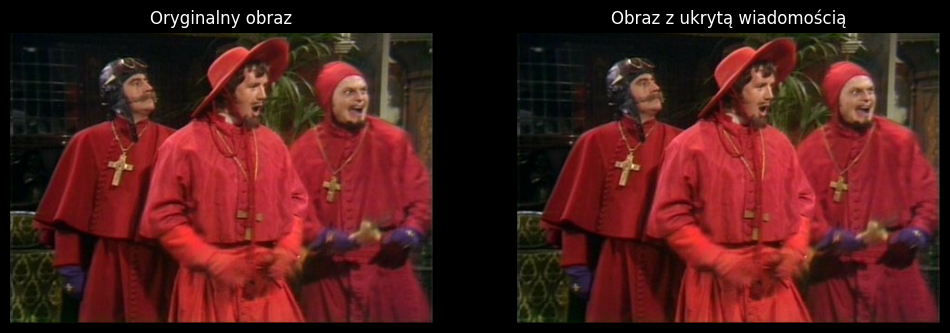

In [16]:
image = load_image("images/spanish.png")
msg = "skibidi toilet"
msg_bits = encode_as_binary_array(msg)
img_msg = hide_message_lsb(image, msg_bits)
save_image("images/zad1.png", img_msg)

recovered_bits = reveal_message_lsb(img_msg, nbits=1, length=len(msg_bits))
recovered_txt = decode_from_binary_array(recovered_bits)
print("Odczytana wiadomosc:", recovered_txt)
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Oryginalny obraz")
ax[0].axis("off")
ax[1].imshow(img_msg)
ax[1].set_title("Obraz z ukrytą wiadomością")
ax[1].axis("off")

# Zadanie 2

nbits = 1 MSE = 0.3994385548217665
nbits = 2 MSE = 0.9152710191943768
nbits = 3 MSE = 2.688243444174101
nbits = 4 MSE = 7.8445240991773835
nbits = 5 MSE = 27.24343500173792
nbits = 6 MSE = 80.71639535781871
nbits = 7 MSE = 194.54449609933187
nbits = 8 MSE = 369.98860840767776


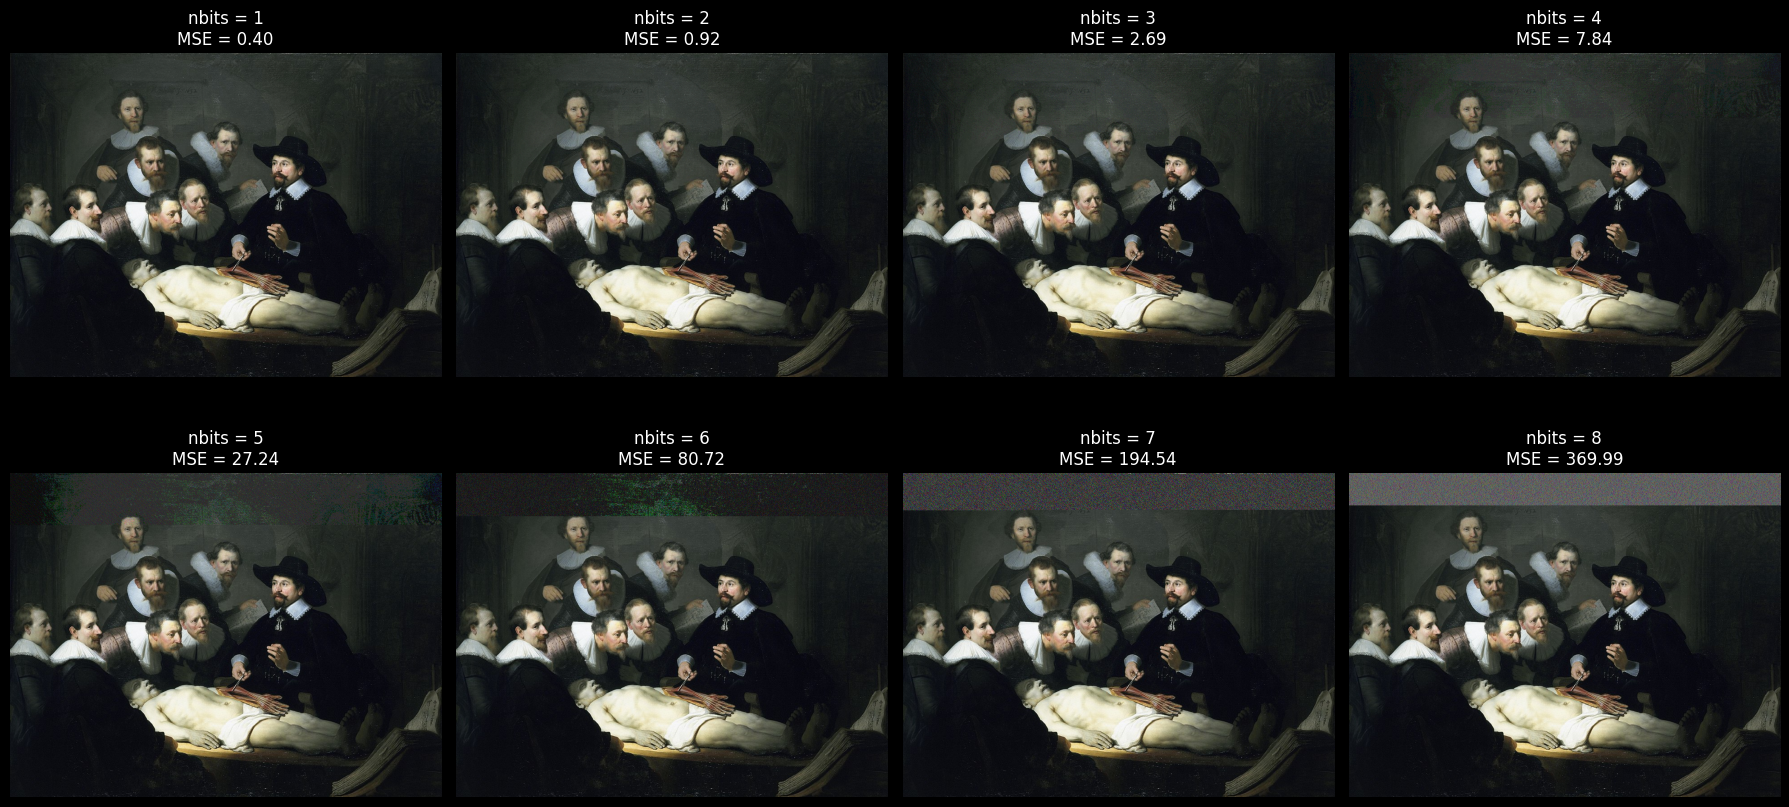

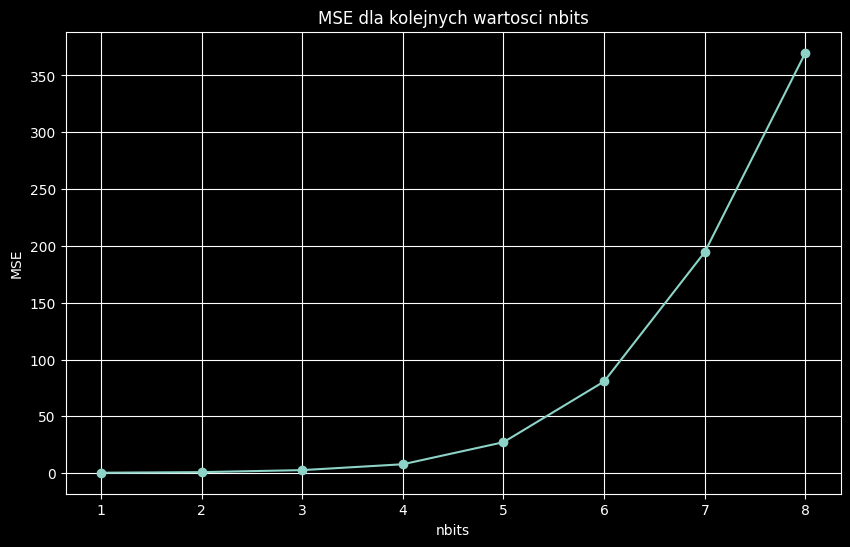

In [21]:
import lorem

def calculateMse(original, modified):
    original = original.astype(np.float64)
    modified = modified.astype(np.float64)
    return np.mean((original - modified) ** 2)


def pad_message_to_nbits(message_bits, nbits):
    rest = len(message_bits) % nbits
    if rest != 0:
        message_bits += "0" * (nbits - rest)
    return message_bits


image = load_image("images/rembrandt.png")

capacity = image.size
target_bits = int(0.8 * capacity)

msg = lorem.paragraph()
chars_needed = math.ceil(target_bits / 8)

while len(msg) < chars_needed:
    msg += " " + lorem.paragraph()

msg_txt = msg[:chars_needed]
msg_bits = encode_as_binary_array(msg_txt)
text_filled = len(msg_bits) / capacity * 100

assert text_filled > 75, "Wiadomosc zajmuje za malo miejsca w obrazie"


nbits_values = range(1, 9)
mse_values = []
images = []

for nbits in nbits_values:
    msg_bits_nbits = pad_message_to_nbits(msg_bits, nbits)

    img_msg = hide_message_lsb(image, msg_bits_nbits, nbits=nbits)

    mse = calculateMse(image, img_msg)

    mse_values.append(mse)
    images.append(img_msg)

    save_image(f"images/zad2_nbits_{nbits}.png", img_msg)

    print("nbits =", nbits, "MSE =", mse)


fig, ax = plt.subplots(2, 4, figsize=(18, 9))
ax = ax.flatten()

for i, nbits in enumerate(nbits_values):
    ax[i].imshow(images[i])
    ax[i].set_title(f"nbits = {nbits}\nMSE = {mse_values[i]:.2f}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(list(nbits_values), mse_values, marker="o")
plt.xlabel("nbits")
plt.ylabel("MSE")
plt.title("MSE dla kolejnych wartosci nbits")
plt.grid(True)
plt.show()

# Zadanie 3

Labore sed quiquia amet eius quaerat quiquia ut. Quisquam quisquam quaerat etincidunt porro consectetur. Adipisci consectetur dolor magnam consectetur magnam modi etincidunt. Numquam dolor voluptatem neque dolor dolor voluptatem. Amet numquam porro eius. Adipisci consectetur ipsum sed dolorem. Adipisci magnam aliquam neque consectetur. Labore porro adipisci eius dolorem non consectetur sed. Etincidunt adipisci sed ipsum tempora sit modi aliquam. Tempora consectetur labore eius etincidunt amet porro. Quiquia sit amet quisquam dolore labore quisquam dolor. Voluptatem quaerat sed dolorem dolorem sed. Tempora dolore magnam tempora ut voluptatem sit consectetur. Quaerat numquam etincidunt consectetur quaerat. Quiquia quaerat aliquam sed dolor neque eius ipsum. Eius sed tempora voluptatem. Quaerat non eius sed sed velit. Neque eius sit est sit neque dolor. Dolorem etincidunt adipisci porro consectetur neque. Non numquam eius quaerat non ut quiquia. Consectetur est consectetur etincidunt dolo

(np.float64(-0.5), np.float64(459.5), np.float64(315.5), np.float64(-0.5))

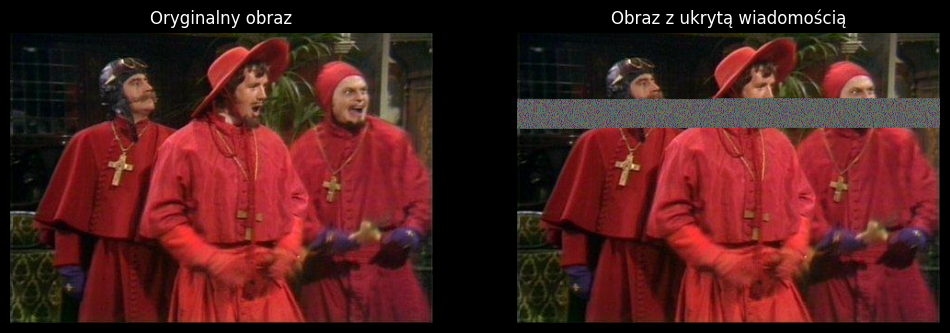

In [44]:
def hide_message(image, message, nbits=1, spos=0):
    """Hide a message in an image (LSB).

    nbits: number of least significant bits
    """

    nbits = clamp(nbits, 1, 8)
    shape = image.shape
    image = np.copy(image).flatten()

    if spos < 0 or spos >= len(image):
        raise ValueError("Invalid pos value")

    if len(message) > (len(image) - spos) * nbits:
        raise ValueError("Message is to long :(")

    chunks = [message[i:i + nbits] for i in range(0, len(message), nbits)]
    for i, chunk in enumerate(chunks):
        byte = "{:08b}".format(image[spos+i])
        new_byte = byte[:-nbits] + chunk
        image[spos+i] = int(new_byte, 2)

    return image.reshape(shape)


def reveal_message(image, nbits=1, length=0, spos=0):
    """Reveal the hidden message.

    nbits: number of least significant bits
    length: length of the message in bits.
    """
    nbits = clamp(nbits, 1, 8)
    shape = image.shape
    image = np.copy(image).flatten()

    if spos < 0 or spos >= len(image):
        raise ValueError("Invalid pos value")

    length_in_pixels = math.ceil(length / nbits)
    if len(image) < length_in_pixels or length_in_pixels <= 0:
        length_in_pixels = len(image)

    message = ""
    i = 0
    while i < length_in_pixels:
        byte = "{:08b}".format(image[spos + i])
        message += byte[-nbits:]
        i += 1

    mod = length % -nbits
    if mod != 0:
        message = message[:mod]
    return message



image = load_image("images/spanish.jpg")

capacity = image.size
target_bits = int(0.8 * capacity)

msg = lorem.paragraph()
chars_needed = math.ceil(target_bits / 8)

while len(msg) < chars_needed:
    msg += " " + lorem.paragraph()
msg_bits = encode_as_binary_array(msg)

spos = 100000

img_msg = hide_message(image, msg_bits, nbits=8, spos=spos)

revealed_bits = reveal_message(img_msg, nbits=8, length=len(msg_bits), spos=spos)
revealed_msg = decode_from_binary_array(revealed_bits)

print(revealed_msg)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Oryginalny obraz")
ax[0].axis("off")
ax[1].imshow(img_msg)
ax[1].set_title("Obraz z ukrytą wiadomością")
ax[1].axis("off")

# Zadanie 4

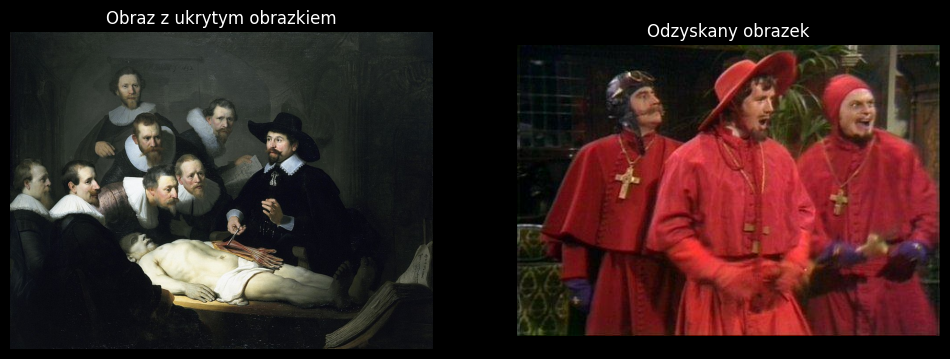

In [41]:
def decode_image(image, length, nbits=1):
    """
    image  - obrazek z ukrytym obrazkiem
    length - dlugosc ukrytego obrazka w bitach
    nbits  - liczba najmniej znaczacych bitow uzyta do zakodowania obrazka
    """
    nbits = clamp(nbits, 1, 8)
    hidden_bits = reveal_message(image, nbits=nbits, length=length)

    hidden_bytes_list = []

    for i in range(0, len(hidden_bits), 8):
        byte_bits = hidden_bits[i:i + 8]      # bierzemy 8 bitow
        byte_value = int(byte_bits, 2)        # zamieniamy "01000001" na liczbe
        hidden_bytes_list.append(byte_value)  # dodajemy bajt do listy

    hidden_bytes = bytes(hidden_bytes_list)

    return hidden_bytes


image = load_image("images/rembrandt.png")

image_with_secret, length_of_secret = hide_image(image, "images/spanish.jpg", nbits=1)
decoded_image = decode_image(image_with_secret, length_of_secret, nbits=1)

with open("images/decoded_spanish.jpg", "wb") as file:
    file.write(decoded_image)

recovered_image = load_image("images/decoded_spanish.jpg")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image_with_secret)
ax[0].set_title("Obraz z ukrytym obrazkiem")
ax[0].axis("off")

ax[1].imshow(recovered_image)
ax[1].set_title("Odzyskany obrazek")
ax[1].axis("off")

plt.show()

# Zadanie 5

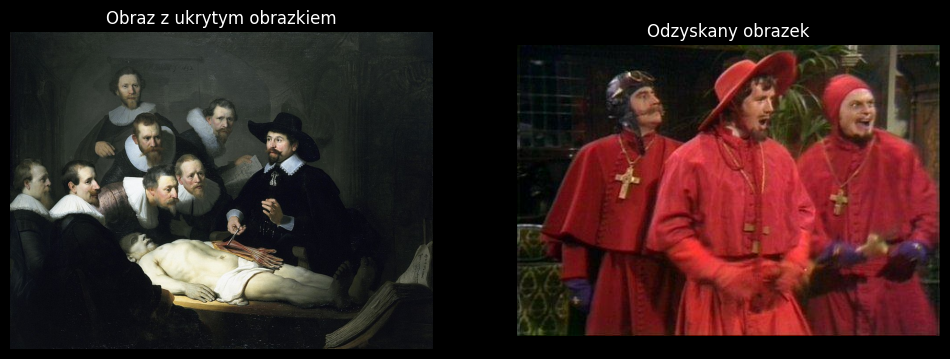

In [43]:
def decode_image_nolenght(image, nbits=1):
    nbits = clamp(nbits, 1, 8)
    image = np.copy(image).flatten()

    bits = ""
    hidden_bytes = bytearray()

    for value in image:
        byte = "{:08b}".format(value)
        bits += byte[-nbits:]

        if len(bits) >= 8:
            byte_bits = bits[:8]
            bits = bits[8:]

            byte_value = int(byte_bits, 2)
            hidden_bytes.append(byte_value)

            if len(hidden_bytes) >= 2:
                if hidden_bytes[-2] == 0xFF and hidden_bytes[-1] == 0xD9:
                    return bytes(hidden_bytes)

    raise ValueError("Nie znaleziono stopki pliku JPEG")

image = load_image("images/rembrandt.png")

image_with_secret, _ = hide_image(image, "images/spanish.jpg", nbits=1)
decoded_image = decode_image_nolenght(image_with_secret, nbits=1)

with open("images/decoded_spanish2.jpg", "wb") as file:
    file.write(decoded_image)

recovered_image = load_image("images/decoded_spanish2.jpg")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image_with_secret)
ax[0].set_title("Obraz z ukrytym obrazkiem")
ax[0].axis("off")

ax[1].imshow(recovered_image)
ax[1].set_title("Odzyskany obrazek")
ax[1].axis("off")

plt.show()